# Limpieza y Modelado Logistico con Random Forest

Notebook para cargar `dataset_logistico.csv`, limpiar las variables necesarias y entrenar un modelo `RandomForestRegressor` para predecir `sale_amount`.

## 1. Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

## 2. Carga del dataset

In [13]:


df = pd.read_csv("../../data/dataset_logistico_1.csv")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.head()

Filas: 100,000
Columnas: 22


,dt,sale_amount,product_id,name_products,tipo_producto_app,store_id,first_category_id,second_category_id,third_category_id,discount,...,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
0,2024-03-28,68.64,001,Metotrexato 500mg,Clinico,0,20,50,24,0.996,...,3,28,3,0,3,NaN,NaN,NaN,NaN,NaN
1,2024-03-29,67.59,001,Metotrexato 500mg,Clinico,0,20,50,24,0.997,...,3,29,4,0,0,68.64,NaN,68.6400,68.6400,3.0
2,2024-03-30,69.27,001,Metotrexato 500mg,Clinico,0,20,50,24,1.000,...,3,30,5,1,0,67.59,NaN,68.1150,68.1150,0.0
3,2024-03-31,69.23,001,Metotrexato 500mg,Clinico,0,20,50,24,0.999,...,3,31,6,1,2,69.27,NaN,68.5000,68.5000,0.0
4,2024-04-01,68.56,001,Metotrexato 500mg,Clinico,0,20,50,24,0.997,...,4,1,0,0,2,69.23,NaN,68.6825,68.6825,2.0


## 3. Revision inicial

In [14]:
df.info()

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

print(f"\nFilas duplicadas: {df.duplicated().sum():,}")

display(df.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   dt                  100000 non-null  str    
 1   sale_amount         100000 non-null  float64
 2   product_id          100000 non-null  str    
 3   name_products       100000 non-null  str    
 4   tipo_producto_app   100000 non-null  str    
 5   store_id            100000 non-null  int64  
 6   first_category_id   100000 non-null  int64  
 7   second_category_id  100000 non-null  int64  
 8   third_category_id   100000 non-null  int64  
 9   discount            100000 non-null  float64
 10  holiday_flag        100000 non-null  int64  
 11  activity_flag       100000 non-null  int64  
 12  mes                 100000 non-null  int64  
 13  dia_mes             100000 non-null  int64  
 14  dia_semana          100000 non-null  int64  
 15  fin_semana          100000 non-null  int64  
 

,nulos
venta_lag_7,7784
venta_promedio_14d,1112
venta_promedio_7d,1112
venta_lag_1,1112
stock_lag_1,1112
dt,0
store_id,0
tipo_producto_app,0
name_products,0
product_id,0



Filas duplicadas: 0


,dt,sale_amount,product_id,name_products,tipo_producto_app,store_id,first_category_id,second_category_id,third_category_id,discount,...,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
count,100000,100000.000000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,98888.00000,92216.000000,98888.000000,98888.000000,98888.000000
unique,90,NaN,273,273,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-03-28,NaN,010,Cateter Endovenoso 24G,Producto general,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1112,NaN,1170,1170,45640,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,42.504576,NaN,NaN,NaN,19.051300,14.690500,44.087200,111.94060,0.914588,...,4.855430,15.599830,3.011140,0.288890,8.103640,42.48058,42.340520,42.299377,42.139008,8.109922
std,NaN,15.398641,NaN,NaN,NaN,14.043854,8.943753,21.832622,60.44367,0.113639,...,0.876434,8.806865,2.008277,0.453249,4.106225,15.39980,15.392883,13.739343,13.543317,4.106576
min,NaN,14.110000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.00000,0.358000,...,3.000000,1.000000,0.000000,0.000000,0.000000,14.11000,14.110000,14.110000,14.110000,0.000000
25%,NaN,29.580000,NaN,NaN,NaN,2.000000,4.000000,28.000000,66.00000,0.851000,...,4.000000,8.000000,1.000000,0.000000,5.000000,29.58000,29.580000,31.058214,30.989821,5.000000
50%,NaN,41.120000,NaN,NaN,NaN,18.000000,16.000000,33.000000,105.00000,0.988000,...,5.000000,15.000000,3.000000,0.000000,9.000000,41.12000,41.120000,39.171429,38.882143,9.000000
75%,NaN,55.070000,NaN,NaN,NaN,29.000000,21.000000,64.000000,167.00000,1.000000,...,6.000000,23.000000,5.000000,1.000000,11.000000,55.07000,55.070000,52.907143,52.530179,11.000000


## 4. Limpieza y preparacion

In [15]:
df = df.copy()

df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

# Eliminamos filas con problemas basicos en fecha o variable objetivo.
df = df.dropna(subset=["dt", "sale_amount"]).copy()

# Eliminamos duplicados exactos.
df = df.drop_duplicates().copy()

# Codificacion simple con pandas para variables categoricas.
columnas_categoricas = [
    "product_id",
    "store_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "holiday_flag",
    "activity_flag",
]

for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype("category")
        df[f"{col}_cod"] = df[col].cat.codes

print(f"Filas despues de limpieza: {len(df):,}")
display(df.head())

Filas despues de limpieza: 100,000


,dt,sale_amount,product_id,name_products,tipo_producto_app,store_id,first_category_id,second_category_id,third_category_id,discount,...,venta_promedio_7d,venta_promedio_14d,stock_lag_1,product_id_cod,store_id_cod,first_category_id_cod,second_category_id_cod,third_category_id_cod,holiday_flag_cod,activity_flag_cod
0,2024-03-28,68.64,001,Metotrexato 500mg,Clinico,0,20,50,24,0.996,...,NaN,NaN,NaN,0,0,14,35,15,0,0
1,2024-03-29,67.59,001,Metotrexato 500mg,Clinico,0,20,50,24,0.997,...,68.6400,68.6400,3.0,0,0,14,35,15,0,0
2,2024-03-30,69.27,001,Metotrexato 500mg,Clinico,0,20,50,24,1.000,...,68.1150,68.1150,0.0,0,0,14,35,15,1,0
3,2024-03-31,69.23,001,Metotrexato 500mg,Clinico,0,20,50,24,0.999,...,68.5000,68.5000,0.0,0,0,14,35,15,1,0
4,2024-04-01,68.56,001,Metotrexato 500mg,Clinico,0,20,50,24,0.997,...,68.6825,68.6825,2.0,0,0,14,35,15,0,0


## 5. Variables para el modelo

In [16]:
TARGET = "sale_amount"

FEATURES = [
    "product_id_cod",
    "store_id_cod",
    "first_category_id_cod",
    "second_category_id_cod",
    "third_category_id_cod",
    "discount",
    "holiday_flag_cod",
    "activity_flag_cod",
    "mes",
    "dia_mes",
    "dia_semana",
    "fin_semana",
    "horas_con_stock",
    "venta_lag_1",
    "venta_lag_7",
    "venta_promedio_7d",
    "venta_promedio_14d",
    "stock_lag_1",
]

features_existentes = [col for col in FEATURES if col in df.columns]

df_modelo = df[["dt", TARGET] + features_existentes].dropna().sort_values("dt").reset_index(drop=True)

print("Target:", TARGET)
print("Features utilizadas:")
for feature in features_existentes:
    print("-", feature)

print(f"\nFilas finales para modelado: {len(df_modelo):,}")
display(df_modelo.head())

Target: sale_amount
Features utilizadas:
- product_id_cod
- store_id_cod
- first_category_id_cod
- second_category_id_cod
- third_category_id_cod
- discount
- holiday_flag_cod
- activity_flag_cod
- mes
- dia_mes
- dia_semana
- fin_semana
- horas_con_stock
- venta_lag_1
- venta_lag_7
- venta_promedio_7d
- venta_promedio_14d
- stock_lag_1

Filas finales para modelado: 92,216


,dt,sale_amount,product_id_cod,store_id_cod,first_category_id_cod,second_category_id_cod,third_category_id_cod,discount,holiday_flag_cod,activity_flag_cod,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
0,2024-04-04,69.55,0,0,14,35,15,0.997,1,0,4,4,3,0,4,66.14,68.64,68.308571,68.308571,0.0
1,2024-04-04,35.07,153,1,15,44,142,1.000,1,0,4,4,3,0,12,24.65,17.60,30.145714,30.145714,12.0
2,2024-04-04,35.07,169,9,18,36,91,1.000,1,0,4,4,3,0,10,35.07,32.04,30.890000,30.890000,10.0
3,2024-04-04,28.52,152,1,15,44,115,1.000,1,0,4,4,3,0,10,17.60,28.52,23.201429,23.201429,15.0
4,2024-04-04,35.07,172,9,24,60,147,0.849,1,1,4,4,3,0,10,24.65,28.52,29.355714,29.355714,12.0


## 6. Division cronologica train-test

In [17]:
X = df_modelo.drop(["dt", TARGET], axis=1)
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Train: {len(X_train):,} filas")
print(f"Test: {len(X_test):,} filas")
print(f"Columnas predictoras: {X_train.shape[1]}")

Train: 73,772 filas
Test: 18,444 filas
Columnas predictoras: 18


## 7. Entrenamiento con RandomForestRegressor

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## 8. Evaluacion

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

resultados = pd.DataFrame({
    "dt": df_modelo.loc[X_test.index, "dt"].values,
    "real": y_test.values,
    "pred": y_pred,
    "error_abs": np.abs(y_test.values - y_pred)
})

display(resultados.head())

MAE  : 3.3573
RMSE : 4.4555
R2   : 0.9171


,dt,real,pred,error_abs
0,2024-04-27,37.58,37.800364,0.220364
1,2024-06-11,32.04,27.229604,4.810396
2,2024-05-07,35.07,34.223546,0.846454
3,2024-04-25,20.87,20.478822,0.391178
4,2024-06-25,32.04,31.397840,0.642160


## 9. Graficos del modelo

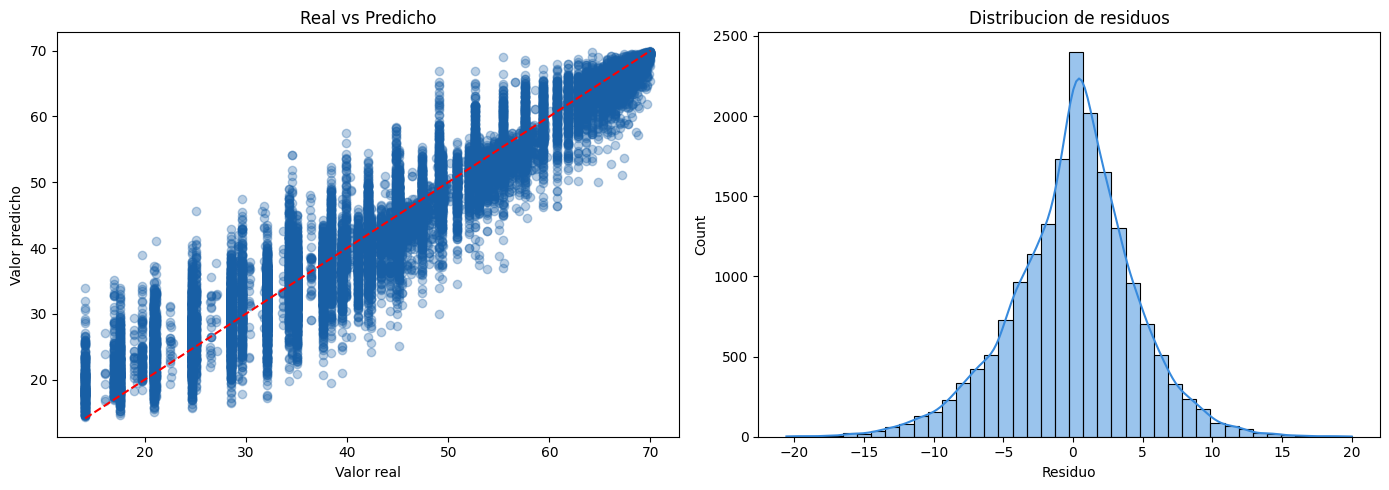

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, color="#185FA5")
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limites, limites, "r--")
axes[0].set_title("Real vs Predicho")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Valor predicho")

residuos = y_test.values - y_pred
sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color="#378ADD")
axes[1].set_title("Distribucion de residuos")
axes[1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()

## 10. Importancia de variables

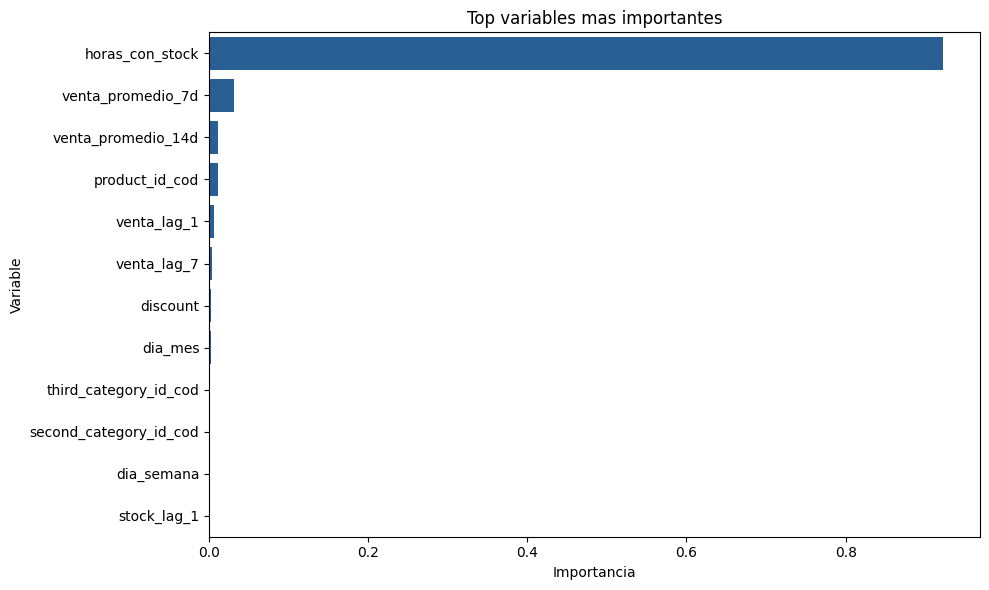

,importancia
horas_con_stock,0.922705
venta_promedio_7d,0.031603
venta_promedio_14d,0.011890
product_id_cod,0.010944
venta_lag_1,0.005931
venta_lag_7,0.003265
discount,0.002933
dia_mes,0.001853
third_category_id_cod,0.001644
second_category_id_cod,0.001303


In [21]:
importancias = pd.Series(rf.feature_importances_, index=features_existentes).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values[:12], y=importancias.index[:12], color="#185FA5")
plt.title("Top variables mas importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(importancias.to_frame("importancia"))

## 11. Guardar resultados en JSON

In [22]:
import json
import pickle
from pathlib import Path

posibles_rutas = [Path("../../data"), Path("../data"), Path("data"), Path(".")]
carpeta_salida = next((ruta for ruta in posibles_rutas if ruta.exists()), Path("."))
ruta_json = carpeta_salida / "resultados_modelo_logistico.json"
ruta_modelo = carpeta_salida / "modelo_logistico.pkl"

grafico_diario = (
    resultados.assign(dt=pd.to_datetime(resultados["dt"], errors="coerce"))
    .dropna(subset=["dt"])
    .groupby("dt", as_index=False)
    .agg(real=("real", "sum"), pred=("pred", "sum"))
    .sort_values("dt")
)

resultados_logistico = {
    "modelo": "RandomForestRegressor",
    "metricas": {
        "mae": round(float(mae), 4),
        "rmse": round(float(rmse), 4),
        "r2": round(float(r2), 4)
    },
    "serie_diaria": grafico_diario.to_dict(orient="records"),
    "top_variables": importancias.head(10).round(6).to_dict()
}

with open(ruta_json, "w", encoding="utf-8") as archivo:
    json.dump(resultados_logistico, archivo, ensure_ascii=False, indent=4, default=str)

payload_modelo_logistico = {
    "modelo": rf,
    "features": list(X.columns),
    "target": TARGET
}

with open(ruta_modelo, "wb") as archivo_modelo:
    pickle.dump(payload_modelo_logistico, archivo_modelo)

print(f"Resultados logisticos guardados en: {ruta_json}")
print(f"Modelo logistico guardado en: {ruta_modelo}")
resultados_logistico

Resultados logisticos guardados en: ..\..\data\resultados_modelo_logistico.json
Modelo logistico guardado en: ..\..\data\modelo_logistico.pkl


{'modelo': 'RandomForestRegressor',
 'metricas': {'mae': 3.3573, 'rmse': 4.4555, 'r2': 0.9171},
 'serie_diaria': [{'dt': Timestamp('2024-04-04 00:00:00'),
   'real': 8868.99,
   'pred': 8756.152170632977},
  {'dt': Timestamp('2024-04-05 00:00:00'),
   'real': 8362.63,
   'pred': 8410.562833167809},
  {'dt': Timestamp('2024-04-06 00:00:00'),
   'real': 10924.26,
   'pred': 10778.53961164754},
  {'dt': Timestamp('2024-04-07 00:00:00'),
   'real': 7915.04,
   'pred': 7957.452895538601},
  {'dt': Timestamp('2024-04-08 00:00:00'),
   'real': 7686.75,
   'pred': 7695.63612953289},
  {'dt': Timestamp('2024-04-09 00:00:00'),
   'real': 9246.64,
   'pred': 9107.748829202183},
  {'dt': Timestamp('2024-04-10 00:00:00'),
   'real': 9560.09,
   'pred': 9535.811218548737},
  {'dt': Timestamp('2024-04-11 00:00:00'),
   'real': 9359.68,
   'pred': 9504.761764477147},
  {'dt': Timestamp('2024-04-12 00:00:00'),
   'real': 9711.15,
   'pred': 9505.82235518654},
  {'dt': Timestamp('2024-04-13 00:00:00'),
